<a href="https://colab.research.google.com/github/CRAdharsh/ACM_Task_C.R.Adharsh/blob/main/DL_Final_Code_improvised_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# imports

# Standard library
import os
import zipfile
from collections import Counter

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing import image, ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, VGG16, InceptionV3, MobileNetV2, DenseNet121,
    Xception, EfficientNetB0, NASNetMobile, EfficientNetV2B0, ConvNeXtBase
)

# Colab-specific
from google.colab import files


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class CombinedGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_gen, meta_array, batch_size):
        self.image_gen = image_gen
        self.meta_array = meta_array
        self.batch_size = batch_size

    def __len__(self):
        return len(self.image_gen)

    def __getitem__(self, idx):
        image_batch, label_batch = self.image_gen[idx]
        meta_batch = self.meta_array[idx * self.batch_size : (idx + 1) * self.batch_size]
        return (image_batch, meta_batch), label_batch


In [ ]:
# Upload ZIP file
uploaded = files.upload()

# Unzip uploaded dataset
for fname in uploaded.keys():
    with zipfile.ZipFile(fname, 'r') as zip_ref:
        zip_ref.extractall("lung_cancer_dataset")

# Check extracted folders
os.listdir("lung_cancer_dataset")

Saving Lung_cancer_dataset-20250622T022832Z-1-001.zip to Lung_cancer_dataset-20250622T022832Z-1-001.zip


['Lung_cancer_dataset']

In [ ]:
# 🔧 CONFIG
base_dir = "/content/drive/MyDrive/Lung_cancer_dataset/dataset"
metadata_path = "/content/drive/MyDrive/Lung_cancer_dataset/metadata.csv"
img_size = (224, 224)
batch_size = 32

# ✅ 1. Remove .ipynb_checkpoints if exists
for split in ['train', 'valid', 'test']:
    path = os.path.join(base_dir, split, '.ipynb_checkpoints')
    if os.path.exists(path):
        import shutil
        shutil.rmtree(path)

# ✅ 2. Ensure consistent class ordering
classes = sorted(os.listdir(os.path.join(base_dir, 'train')))

# ✅ 3. Image data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    classes=classes
)

val_data = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'valid'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)

test_data = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)


Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 54 images belonging to 4 classes.


In [ ]:
metadata_df = pd.read_csv(metadata_path)
scaler = StandardScaler()
meta_X = scaler.fit_transform(metadata_df.drop(columns=['filename']))
filename_to_meta = dict(zip(metadata_df['filename'], meta_X))

# ⚖️ Class weights
weights = class_weight.compute_class_weight(class_weight='balanced',
                                            classes=np.unique(train_data.classes),
                                            y=train_data.classes)
class_weights = dict(enumerate(weights))

In [ ]:
def build_combined_model(backbone, input_shape, meta_dim, num_classes):
    # 🧠 Load pre-trained CNN backbone (ImageNet weights)
    cnn_base = backbone(weights='imagenet', include_top=False, input_shape=input_shape)

    # 🔒 Freeze most layers, fine-tune last 30
    for layer in cnn_base.layers[:-30]:
        layer.trainable = False
    for layer in cnn_base.layers[-30:]:
        layer.trainable = True

    # 📷 Image input branch
    cnn_input = cnn_base.input
    x = GlobalAveragePooling2D()(cnn_base.output)
    # x = BatchNormalization()(x)  # Optional for stability

    # 📊 Metadata input branch
    meta_input = Input(shape=(meta_dim,), name='meta_input')
    meta_x = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(meta_input)
    # meta_x = BatchNormalization()(meta_x)  # Optional

    # 🔗 Combine CNN and metadata features
    combined = Concatenate()([x, meta_x])
    combined = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(combined)
    combined = Dropout(0.5)(combined)
    combined = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(combined)
    combined = Dropout(0.3)(combined)

    # 🎯 Output layer for classification
    output = Dense(num_classes, activation='softmax')(combined)

    # 🏗️ Final model
    model = Model(inputs=[cnn_input, meta_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=5e-6), loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [ ]:
def get_meta_batches_safe(data_gen, filename_to_meta):
    filenames = [os.path.basename(path) for path in data_gen.filenames]
    meta = []
    for f in filenames:
        if f in filename_to_meta:
            meta.append(filename_to_meta[f])
        else:
            print(f"⚠️ Warning: Missing metadata for {f}. Using zeros.")
            meta.append(np.zeros(len(next(iter(filename_to_meta.values())))))  # fallback
    return np.array(meta)

In [ ]:
meta_train = get_meta_batches_safe(train_data, filename_to_meta)
meta_val = get_meta_batches_safe(val_data, filename_to_meta)
training_histories = {}

# 🔄 Train each model
trained_models = {}
input_shape = (224, 224, 3)
meta_dim = meta_train.shape[1]
num_classes = len(train_data.class_indices)
backbones = [
    ("resnet", ResNet50),
    ("vgg", VGG16),
    ("inception", InceptionV3),
    ("mobilenet", MobileNetV2),
    ("densenet", DenseNet121),
    ("xception", Xception),
    ("efficientnet", EfficientNetB0),
    ("nasnetmobile", NASNetMobile),
    ("efficientnetv2b0", EfficientNetV2B0),
    ("convnextbase", ConvNeXtBase)
]

batch_size = train_data.batch_size

for name, backbone in backbones:
    print(f"\n🚀 Training model: {name.upper()}")

    train_data.reset()
    val_data.reset()

    # Build the CNN + Metadata model
    model = build_combined_model(backbone, input_shape, meta_dim, num_classes)

    # Create combined generators
    train_combined_gen = CombinedGenerator(train_data, meta_train, batch_size)
    val_combined_gen = CombinedGenerator(val_data, meta_val, batch_size)

    # Train model using combined input
    history = model.fit(
        train_combined_gen,
        validation_data=val_combined_gen,
        epochs=50,
        verbose=1,
        class_weight=class_weights,
        callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
        ]
    )

    trained_models[name] = model
    training_histories[name] = history


⚠️ Warning: Missing metadata for n6 (2) - Copy.jpg. Using zeros.
⚠️ Warning: Missing metadata for n6 (2).jpg. Using zeros.
⚠️ Warning: Missing metadata for n6 - Copy.jpg. Using zeros.
⚠️ Warning: Missing metadata for n6.jpg. Using zeros.
⚠️ Warning: Missing metadata for n8 (2) - Copy.jpg. Using zeros.
⚠️ Warning: Missing metadata for n8 (2).jpg. Using zeros.
⚠️ Warning: Missing metadata for n8 - Copy.jpg. Using zeros.
⚠️ Warning: Missing metadata for n8.jpg. Using zeros.
⚠️ Warning: Missing metadata for n9 (2) - Copy.jpg. Using zeros.
⚠️ Warning: Missing metadata for n9 (2).jpg. Using zeros.
⚠️ Warning: Missing metadata for n9 - Copy.jpg. Using zeros.
⚠️ Warning: Missing metadata for n9.jpg. Using zeros.

🚀 Training model: RESNET
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/27
20/20 ━━━━━━━━━━━━━━━━━━━━ 236s 11s/step - accuracy: 0.2843 - loss: 1.7560 - val_accuracy: 0.3194 - val_loss: 1.6907 - learning_rate: 5.0000e-06
Epoch 2/27
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 604ms/step - accuracy: 0.4048 - loss: 1.5242 - val_accuracy: 0.3472 - val_loss: 1.6618 - learning_rate: 5.0000e-06
Epoch 3/27
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 609ms/step - accuracy: 0.4171 - loss: 1.4836 - val_accuracy: 0.2917 - val_loss: 1.6337 - learning_rate: 5.0000e-06
Epoch 4/27
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 610ms/step - accuracy: 0.4616 - loss: 1.4410 - val_accuracy: 0.3333 - val_loss: 1.6095 - learning_rate: 5.0000e-06
Epoch 5/27
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 619ms/step - accuracy: 0.4533 - loss: 1.3993 - val_accuracy: 0.4306 - val_loss: 1.5861 - learning_rate: 5.0000e-06
Epoch 6/27
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 605ms/step - accuracy: 0.5092 - loss: 1.3745 - val_accuracy: 0.4444 - val_loss: 1.5569 - learning_rate: 5.0000e-06
Epoch 7/27
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 622ms/step - accu

In [ ]:
# ✅ 1. Clean unwanted class entries (like .ipynb_checkpoints)
if ".ipynb_checkpoints" in val_data.class_indices:
    del val_data.class_indices[".ipynb_checkpoints"]

# 📦 2. Access your trained models dictionary
models = [
    trained_models['resnet'],
    trained_models['vgg'],
    trained_models['inception'],
    trained_models['mobilenet'],
    trained_models['densenet'],
    trained_models['xception'],
    trained_models['efficientnet']
]

# 🎚️ 3. Weights for ensemble voting (adjust these based on validation performance)
weights = [
    0.1630,  # ResNet
    0.1630,  # VGG
    0.1586,  # Inception
    0.1101,  # MobileNet
    0.1409,  # DenseNet
    0.1630,  # Xception
    0.1014   # EfficientNet
]

# 🧪 4. Metadata alignment
val_filenames = [os.path.basename(path) for path in val_data.filenames]
val_meta = np.array([filename_to_meta[f] for f in val_filenames])
assert len(val_meta) == val_data.samples, "⚠️ Metadata length mismatch with validation samples"

# 🔄 5. Prediction function (avoids retracing warnings)
def get_model_predictions(model, data_gen, meta_inputs, batch_size):
    preds = []
    data_gen.reset()
    for i in range(len(data_gen)):
        img_batch, _ = data_gen[i]
        meta_batch = meta_inputs[i * batch_size : (i + 1) * batch_size]
        pred = model.predict([img_batch, meta_batch], verbose=0)
        preds.append(pred)
    return np.vstack(preds)

# 🔮 6. Weighted Ensemble Prediction
def ensemble_predict_weighted(models, data_gen, meta_inputs, weights, batch_size):
    total_pred = None
    for model, weight in zip(models, weights):
        pred = get_model_predictions(model, data_gen, meta_inputs, batch_size)
        if total_pred is None:
            total_pred = pred * weight
        else:
            total_pred += pred * weight
    return np.argmax(total_pred, axis=1)

# 🎯 7. Run the ensemble prediction
val_data.reset()
true_labels = val_data.classes
ensemble_preds = ensemble_predict_weighted(models, val_data, val_meta, weights, batch_size)

# 📊 8. Evaluation
print("🔢 Predicted class indices:", np.unique(ensemble_preds))
print("\n✅ Ensemble Classification Report:")
print(classification_report(true_labels, ensemble_preds, target_names=list(val_data.class_indices.keys())))


🔢 Predicted class indices: [0 1 2 3]

✅ Ensemble Classification Report:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.40      0.70      0.51        23
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       1.00      0.10      0.17        21
                                          normal       1.00      1.00      1.00        13
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.41      0.47      0.44        15

                                        accuracy                           0.53        72
                                       macro avg       0.70      0.56      0.53        72
                                    weighted avg       0.69      0.53      0.48        72




📊 Confusion Matrix for ResNet


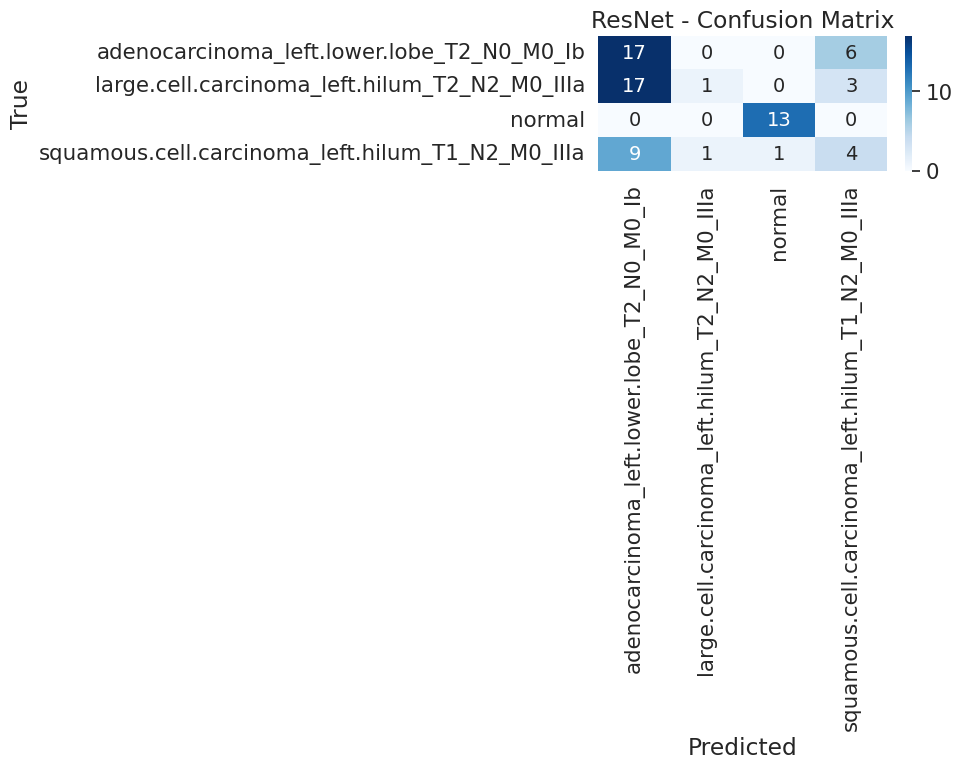


📊 Confusion Matrix for VGG


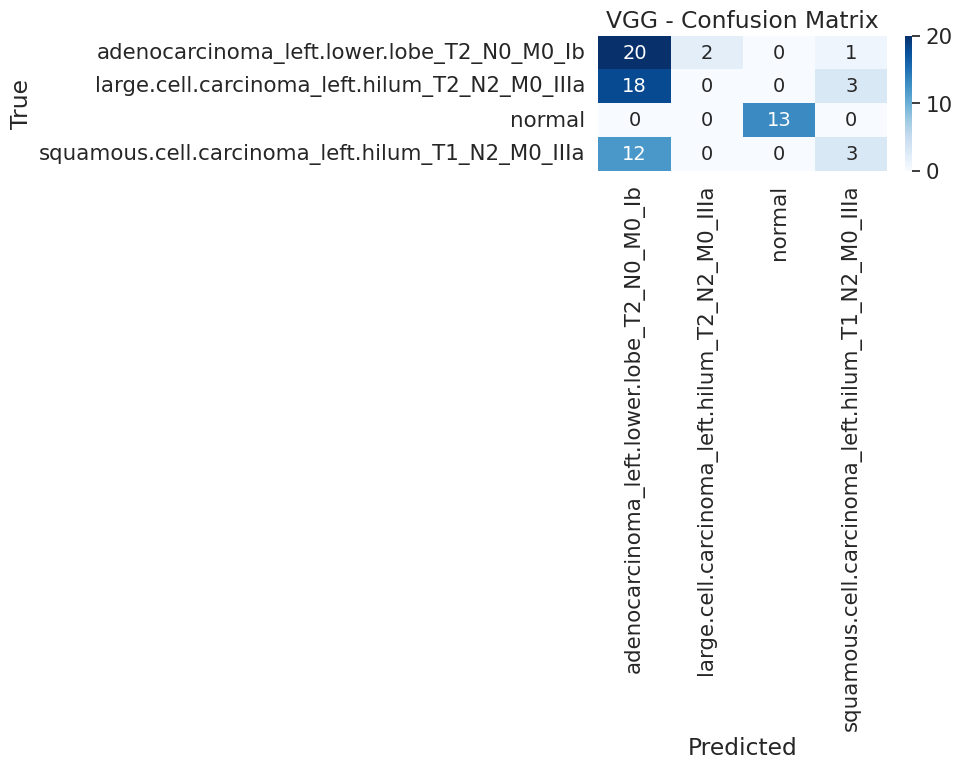


📊 Confusion Matrix for Inception


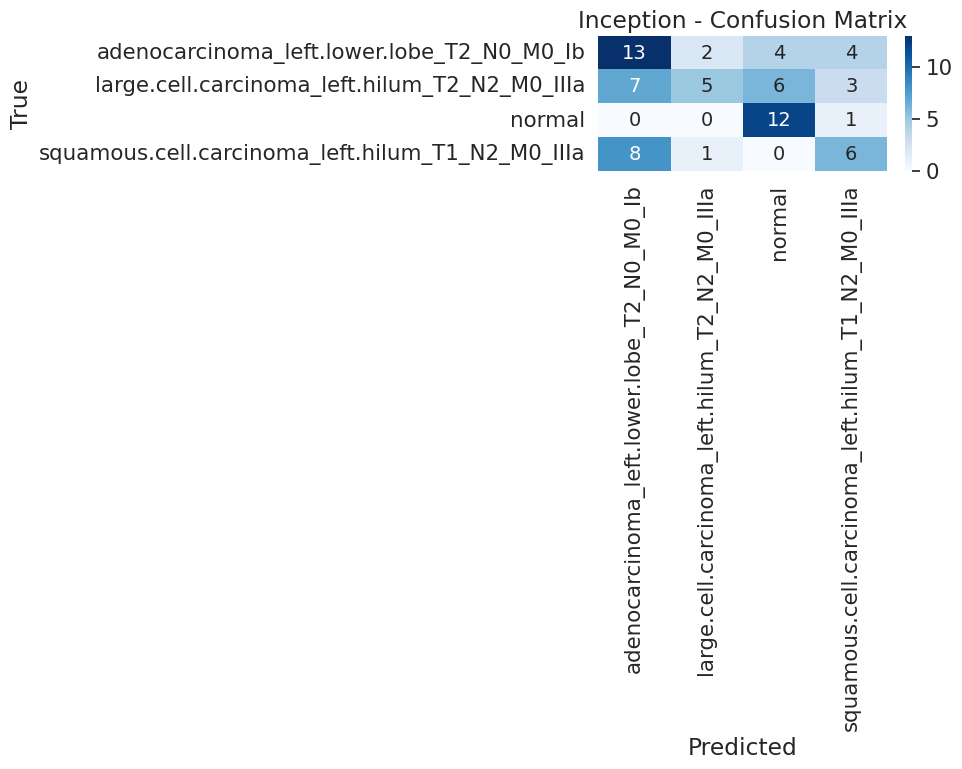


📊 Confusion Matrix for MobileNet


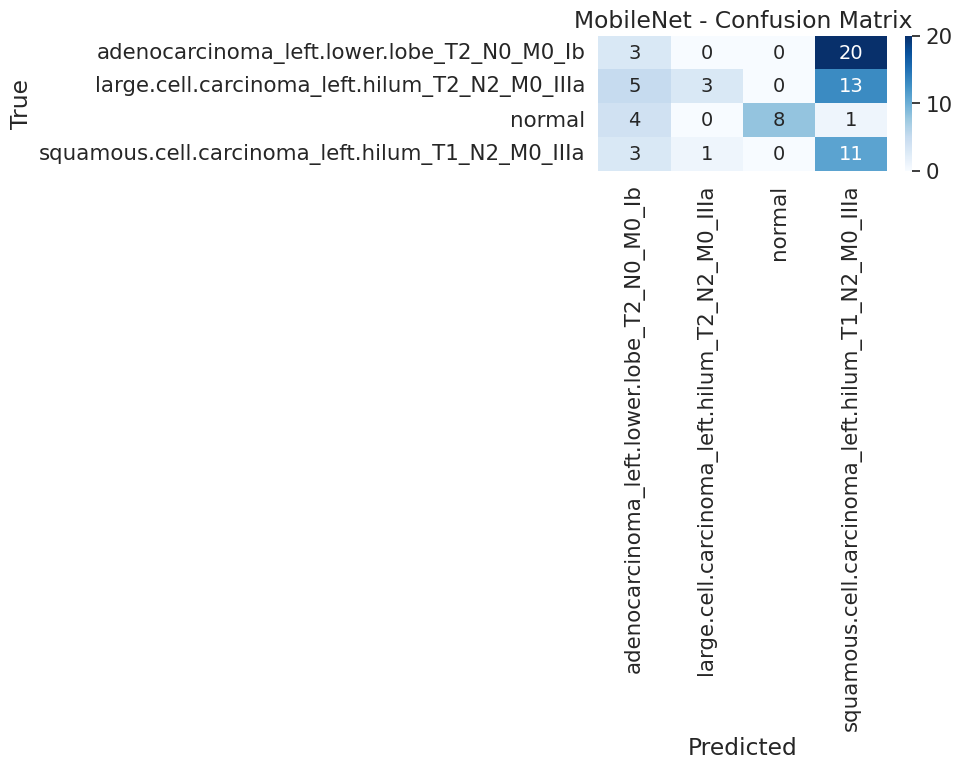


📊 Confusion Matrix for DenseNet


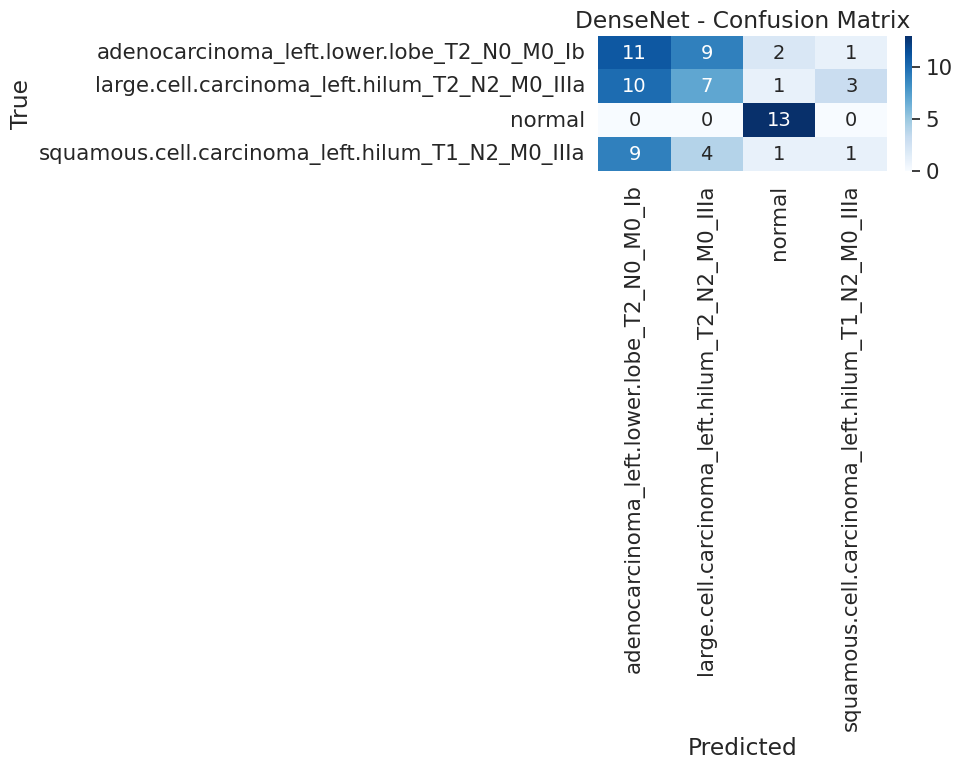


📊 Confusion Matrix for Xception


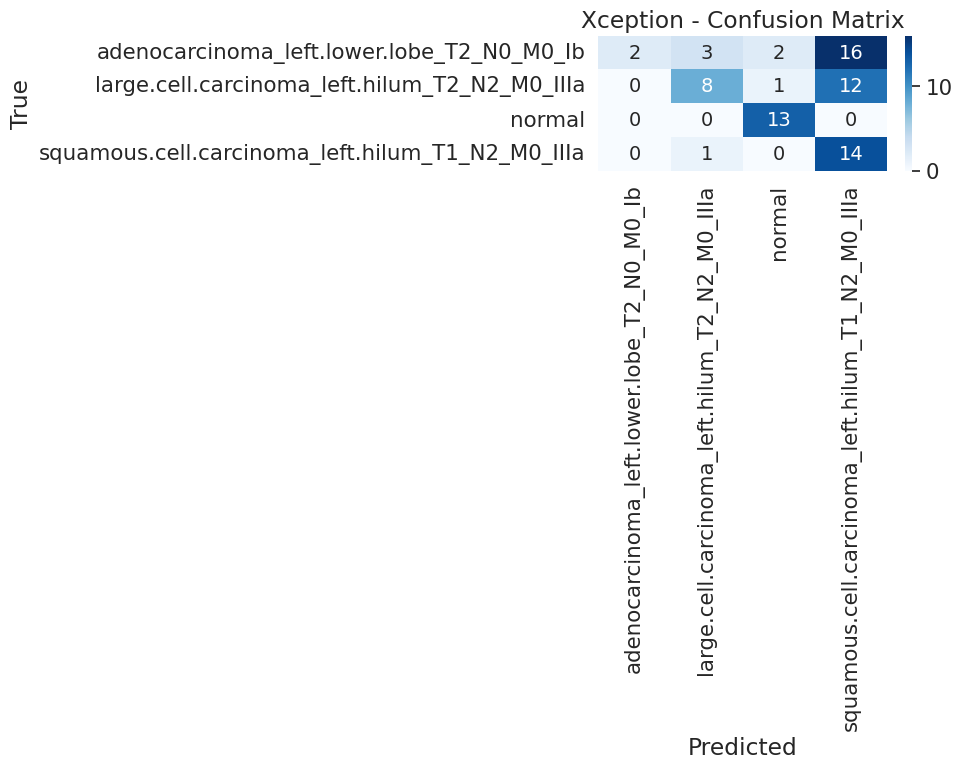


📊 Confusion Matrix for EfficientNet


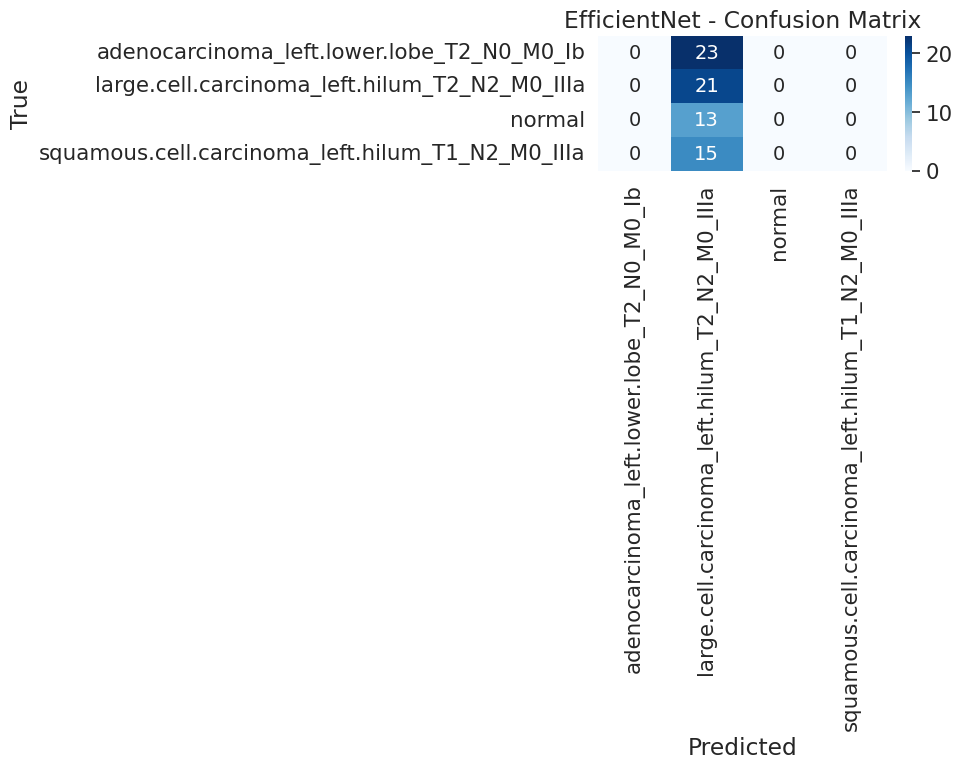


📊 Confusion Matrix for Weighted Ensemble


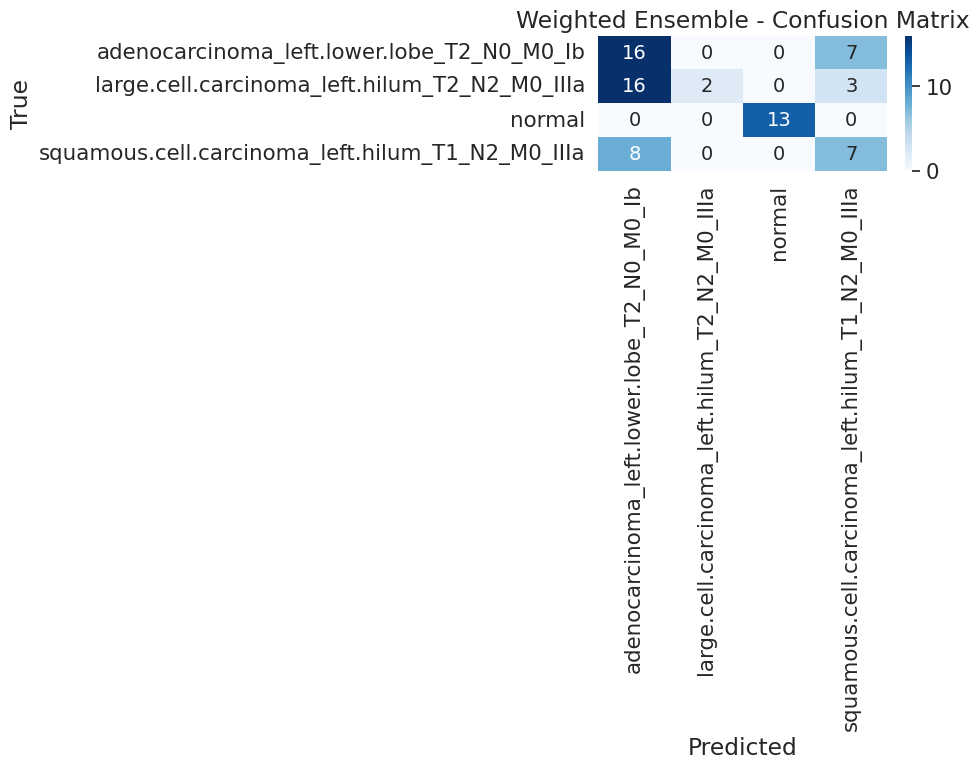

In [ ]:
# 📋 Class names
class_names = list(val_data.class_indices.keys())

# 📌 Function to plot confusion matrix
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(10,8))
    sns.set(font_scale=1.4)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# 🔍 Confusion Matrix for each individual model
for name, model in zip(['ResNet', 'VGG', 'Inception', 'MobileNet', 'DenseNet', 'Xception', 'EfficientNet'], models):
    preds = get_model_predictions(model, val_data, val_meta, batch_size)
    predicted_classes = np.argmax(preds, axis=1)
    cm = confusion_matrix(true_labels, predicted_classes)
    print(f"\n📊 Confusion Matrix for {name}")
    plot_confusion_matrix(cm, model_name=name)

# 🔮 Confusion Matrix for the ensemble
ensemble_cm = confusion_matrix(true_labels, ensemble_preds)
print("\n📊 Confusion Matrix for Weighted Ensemble")
plot_confusion_matrix(ensemble_cm, model_name="Weighted Ensemble")


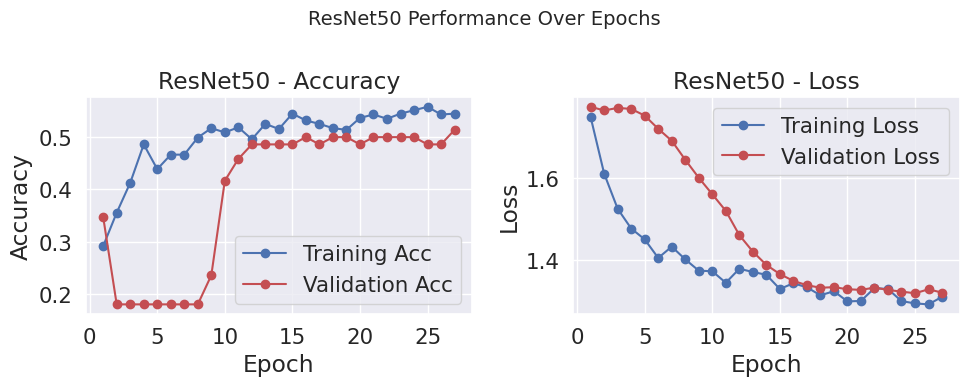

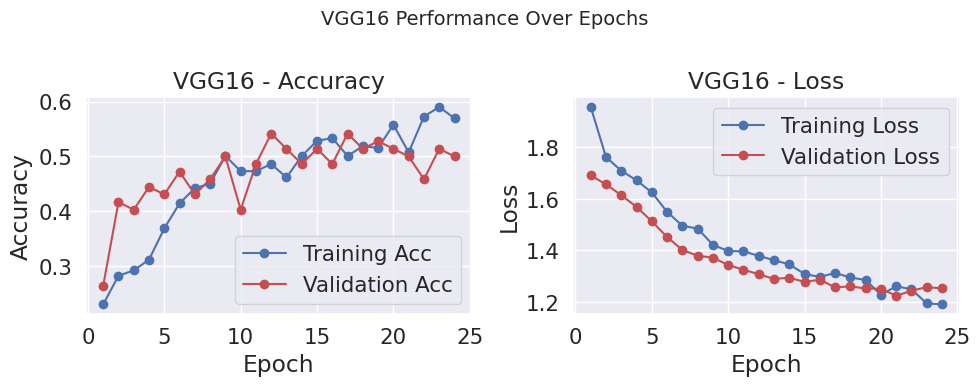

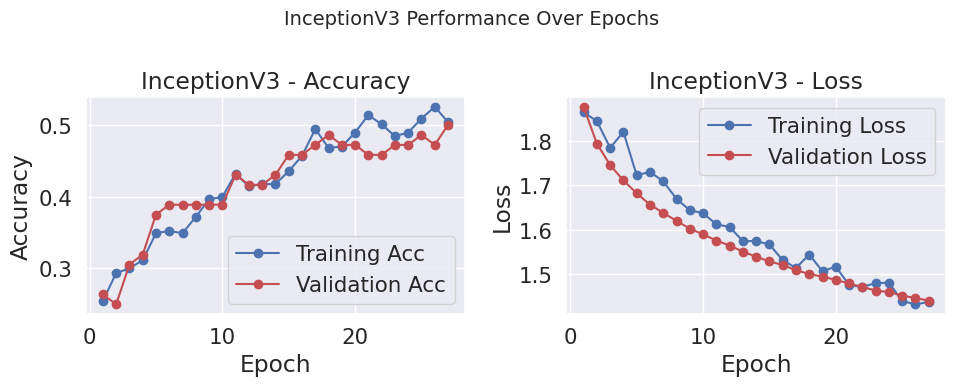

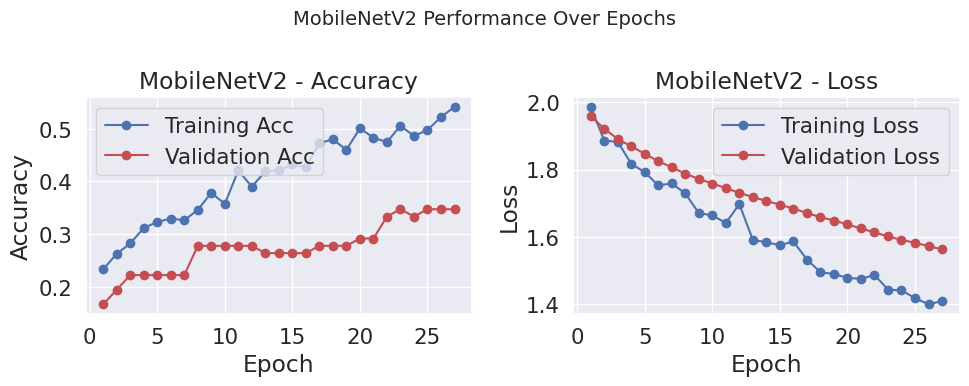

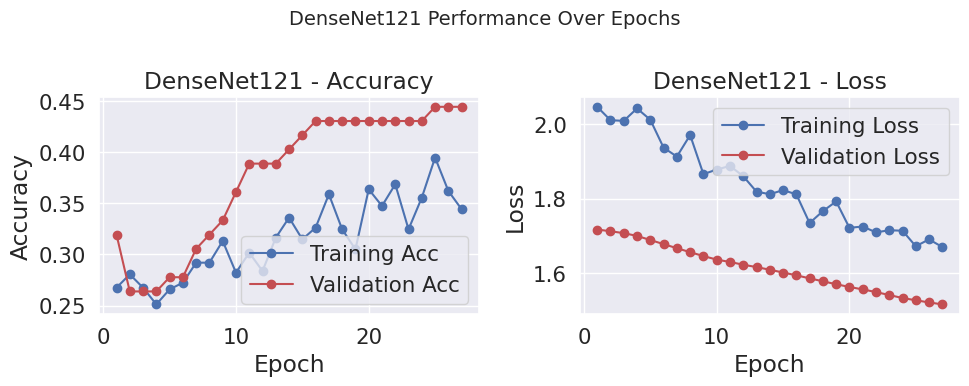

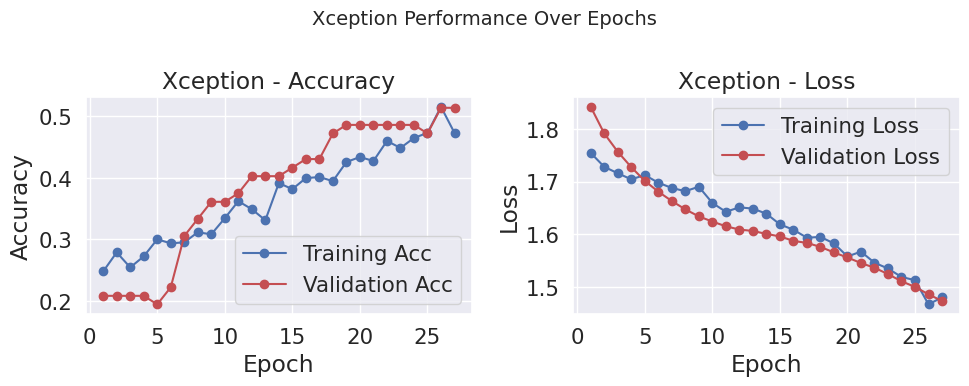

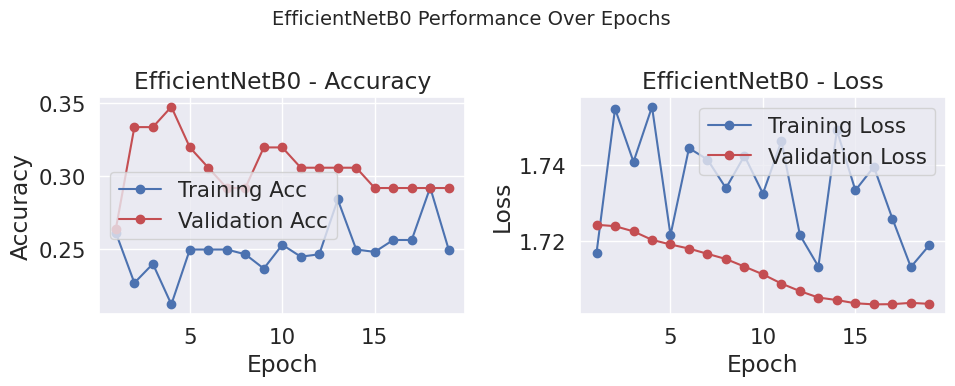

In [ ]:
import matplotlib.pyplot as plt

# ✅ Use your stored training_histories dictionary directly
# Format: training_histories = {"resnet": history, "vgg": history, ...}

# Optional: Friendly display names for plots
display_names = {
    "resnet": "ResNet50",
    "vgg": "VGG16",
    "inception": "InceptionV3",
    "mobilenet": "MobileNetV2",
    "densenet": "DenseNet121",
    "xception": "Xception",
    "efficientnet": "EfficientNetB0"
}

def plot_model_history(histories):
    for key, history in histories.items():
        name = display_names.get(key, key)  # fallback to key if name not found

        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs_range = range(1, len(acc) + 1)

        # 🎯 Accuracy Plot
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc, 'bo-', label='Training Acc')
        plt.plot(epochs_range, val_acc, 'ro-', label='Validation Acc')
        plt.title(f'{name} - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        # 📉 Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
        plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss')
        plt.title(f'{name} - Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.suptitle(f'{name} Performance Over Epochs', fontsize=14)
        plt.tight_layout()
        plt.show()

# 🔧 Run the plot function using your training_histories dict
plot_model_history(training_histories)


Saving test.jpeg to test.jpeg
🧾 Metadata not found for test.jpeg. Please enter 3 comma-separated values:
Metadata: 64,228,89
✅ Image: test.jpeg
🔮 Predicted Class: squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa (42.21%)



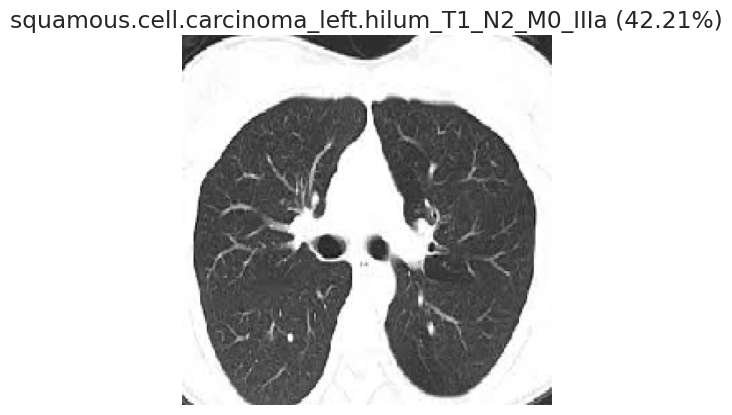

In [ ]:
# 📌 Function: Ensemble Prediction for One Image
def ensemble_predict_single_image(img_array, meta_vector, models, weights):
    predictions = []
    for model, weight in zip(models, weights):
        # Supply both image and meta_vector as needed
        inputs = [img_array, meta_vector] if meta_vector is not None else [img_array]
        pred = model.predict(inputs, verbose=0)
        predictions.append(pred * weight)
    final_pred = np.sum(predictions, axis=0)
    return final_pred

# 📌 Function: Upload & Predict Image Using Ensemble + Metadata
def predict_image_ensemble(img_path, models, class_labels, weights, filename_to_meta=None):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_array_preprocessed = img_array_expanded / 255.0

    # Prepare metadata vector
    base_name = os.path.basename(img_path)
    if filename_to_meta and base_name in filename_to_meta:
        meta_vector = np.expand_dims(filename_to_meta[base_name], axis=0)
    else:
        print(f"🧾 Metadata not found for {base_name}. Please enter {meta_dim} comma-separated values:")
        user_input = input("Metadata: ")
        try:
            meta_values = [float(x.strip()) for x in user_input.split(",")]
            if len(meta_values) != meta_dim:
                raise ValueError(f"Expected {meta_dim} values, got {len(meta_values)}")
            meta_vector = np.expand_dims(np.array(meta_values), axis=0)
        except Exception as e:
            print(f"⚠️ Invalid metadata. Using zeros instead. Error: {e}")
            meta_vector = np.zeros((1, meta_dim))

    # Predict using ensemble
    prediction = ensemble_predict_single_image(img_array_preprocessed, meta_vector, models, weights)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Display result
    print(f"✅ Image: {base_name}")
    print(f"🔮 Predicted Class: {predicted_class} ({confidence:.2f}%)\n")
    plt.imshow(img_array_preprocessed[0])
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence:.2f}%)")
    plt.show()

# 🔼 Upload image(s)
uploaded = files.upload()

# 🎯 Define class labels from validation set
class_labels = list(val_data.class_indices.keys())

# 🔍 Run prediction on uploaded images
for fn in uploaded.keys():
    predict_image_ensemble(fn, models, class_labels, weights, filename_to_meta)


Saving 000109 (2).png to 000109 (2).png
✅ Image: 000109 (2).png
🔮 Predicted Class: adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib (33.06%)



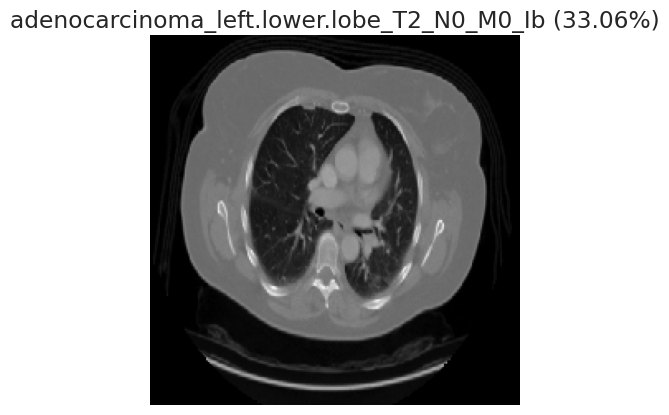

In [ ]:
# 🔼 Upload image(s)
uploaded = files.upload()

# 🎯 Define class labels from validation set
class_labels = list(val_data.class_indices.keys())

# 🔍 Run prediction on uploaded images
for fn in uploaded.keys():
    predict_image_ensemble(fn, models, class_labels, weights, filename_to_meta)
